In [1]:
# Import dependencies

import numpy as np
from tqdm import tqdm
import multiprocessing as mp
import os
from PIL import Image
import rasterio as rio
import matplotlib.pyplot as plt
import glob
import random
from collections import Counter
import pandas as pd
from ship_identification_functions import *


# Patches and their corresponding AIS labels

In [2]:
# Define Data path:

head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"

In [3]:
# A list to hold paths of "folders" including the patches ('ship_patches')

patch_dirs = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    # Check if this folder has no subfolders (i.e., it's a leaf folder)
    if not dirs:
        # Check if the current folder itself is named 'ship_patches'
        if os.path.basename(root) == 'ship_patches':
            patch_dirs.append(root)


# Print the results
# patch_dirs


In [4]:
# tif_dir: A list to hold paths of all the .tif files in the 'ship_patches' directories 
# AIS_df: A DataFrame to hold all the AIS data from the 'AIS.csv' files

import re
tif_dir = []
AIS_df  = []
for p_dirsii in patch_dirs:
    tif_dir.append([])  # Add the directory itself to the list
    # Walk through the directory and find all .tif files
    for root, dirs, files in os.walk(p_dirsii):
        head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
        AIS_dirii = f"{head_dirii}AIS.csv"
        AIS_dfii = pd.read_csv(AIS_dirii)     
        AIS_df.append(AIS_dfii)
        
        scene_pathii = head_dirii+[ f for f in os.listdir(head_dirii) if 'corrected' in f ][0]
        AIS_df[-1]['Scene path'] = scene_pathii
        metadata_pathii = scene_pathii[:-22]+'metadata.xml'
        AIS_df[-1]['Metadata path'] = metadata_pathii

        files = sorted(files, key=lambda x: int(re.search(r'patch_(\d+)', x).group(1)))
        for file in files:
            if file.lower().endswith('.tif'):         
                full_pathii = os.path.join( root, file )
                tif_dir[-1].append( full_pathii )

AIS_df  = pd.concat(AIS_df, ignore_index=True)
tif_dir = [item for sublist in tif_dir for item in sublist]
print(f"Found {len(tif_dir)} patches in {len(patch_dirs)} directories.")


ship_name = AIS_df['Ship type'].tolist()
shoreline = AIS_df['Shoreline'].tolist()
quality   = AIS_df['Quality'].tolist()


AIS_df['Ship type'].value_counts()


Found 3415 patches in 624 directories.


Ship type
Fishing                  769
Cargo                    593
Passenger                389
Tanker                   265
Sailing                  187
Undefined                168
Pleasure                 158
Tug                      146
Other                    145
Dredging                 119
Pilot                    114
SAR                       99
HSC                       76
Military                  60
Law enforcement           38
Port tender               26
Reserved                  18
Towing                    12
Diving                     8
Spare 1                    7
Towing long/wide           5
Anti-pollution             4
Not party to conflict      4
Medical                    3
WIG                        2
Name: count, dtype: int64

In [5]:
AIS_df

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Patch_name,Dist_to_land,Shoreline,Quality,Wake Potential,Wake Quality,Scene path,Metadata path,Unnamed: 32,Unnamed: 31
0,11/01/2024 22:25:34,Base Station,2190049,55.735817,10.918782,Unknown value,NaN,NaN,NaN,NaN,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,927.275478,offshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
1,11/01/2024 22:25:35,Class A,219003966,55.675625,11.102063,Under way using engine,0.0,0.0,351.0,344.0,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,1.419551,inshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
2,11/01/2024 22:25:42,Class A,219023833,55.677365,11.082657,Under way using engine,0.0,0.0,101.1,92.0,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,4.519244,inshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3,11/01/2024 22:25,Class A,219543000,55.619317,10.792550,Under way using engine,0.0,15.7,158.8,160.0,...,NovaSAR_01_51481_grd_13_240111_222543_HH_2_pat...,11248.335833,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
4,11/01/2024 22:25,Class B,219003038,55.059985,10.616735,Unknown value,NaN,0.0,NaN,NaN,...,NovaSAR_01_51481_grd_13_240111_222549_HH_3_pat...,24.686231,inshore,0.0,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,05/06/2024 22:03,Class A,636022446,54.964667,13.826333,Under way using engine,-2.9,12.1,73.0,72.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,3877.721031,offshore,NaN,1.0,0.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3411,05/06/2024 22:03,Class A,230617000,54.985422,13.620405,Under way using engine,2.9,17.5,250.0,250.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,1567.210703,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3412,05/06/2024 22:03,Class A,232026551,54.953547,13.567260,Under way using engine,0.0,10.4,252.2,255.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,5115.630310,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3413,05/06/2024 22:03,AtoN,992111808,54.845067,13.584312,Unknown value,NaN,NaN,NaN,NaN,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,17191.805560,offshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN


Filtering the Data (Quality and In/OffShore)

In [6]:
samples_loc = 'InShoreOffShore'
# samples_loc = 'OffShore'
# samples_loc = 'InShore'
print(f"Samples location selected: {samples_loc}")





# Remove inshore patches and low quality and duplicate (similar) patches:

quality0 = np.array(quality)
quality0[quality0==9]=0

if samples_loc == 'InShoreOffShore':
    tif_dir = [tifii for tifii,qii in zip(tif_dir, quality0) if qii !=0] # Uncomment if only high quality data is needed (both inshore and offshore included)

if samples_loc == 'OffShore':
    tif_dir = [tifii for tifii, shoreii,qii in zip(tif_dir, shoreline, quality0) if shoreii == 'offshore' and qii !=0] # Uncomment if only offshore and high quality data is needed
    AIS_df = AIS_df[AIS_df['Shoreline'] == 'offshore'] # Uncomment if only offshore data is needed

if samples_loc == 'InShore':
    tif_dir = [tifii for tifii, shoreii,qii in zip(tif_dir, shoreline, quality0) if shoreii == 'inshore' and qii !=0] # Uncomment if only inshore and high quality data is needed
    AIS_df = AIS_df[AIS_df['Shoreline'] == 'inshore'] # Uncomment if only onshore data is needed

# -------
AIS_df = AIS_df[ (AIS_df['Quality'] != 0) & (AIS_df['Quality'] != 9) ]
AIS_df.reset_index(drop=True, inplace=True)

ship_name = AIS_df['Ship type'].tolist()
shoreline = AIS_df['Shoreline'].tolist()
quality   = AIS_df['Quality'].tolist()
print(f"\nFound {len(tif_dir)} Patches after filtering...")
AIS_df['Ship type'].value_counts()


Samples location selected: InShoreOffShore

Found 1891 Patches after filtering...


Ship type
Cargo                    486
Passenger                274
Tanker                   239
Fishing                  215
Sailing                   92
Undefined                 85
Dredging                  79
Tug                       72
Other                     64
Pleasure                  64
Pilot                     48
HSC                       41
SAR                       36
Military                  33
Law enforcement           21
Port tender               10
Towing                     9
Reserved                   7
Diving                     5
Spare 1                    3
Anti-pollution             3
Towing long/wide           2
WIG                        1
Not party to conflict      1
Medical                    1
Name: count, dtype: int64

# Load and Prepare the Data


Run if you want to select samples based on their class number: 

In [7]:
# Replace classes with "Other Type" if their count is below a threshold:

# from collections import Counter

# Thresh_class = 55#51#45#40#50#35#40#25#20#27#40#37#27#15#19#35# 30#20  # Threshold for minimum class counts

# # Count frequency of each ship_name
# ship_name_counts = Counter(ship_name)

# # Replace ship_name with "Other Type" if their count is below the threshold
# ship_name_updated = [p if ship_name_counts[p] >= Thresh_class else "Other Type" for p in ship_name]

Run if you want to select samples based on their class name: 

In [8]:
topN=False
# selected_classes = ['Fishing']; topN=True; topN_val = 5
# selected_classes = ['Cargo', 'Fishing']
# selected_classes = ['Cargo', 'Tanker']
# selected_classes = ['Cargo', 'Tanker', 'Fishing']
selected_classes = ['Cargo', 'Tanker', 'Fishing', 'Passenger']


if topN:
    selected_classesTN=AIS_df['Ship type'].value_counts()[:topN_val].index.tolist()
    if selected_classes[0] in selected_classesTN:
        selected_classesTN.remove(selected_classes[0])
    if 'Other' in selected_classesTN:
        selected_classesTN.remove('Other')
    if 'Undefined' in selected_classesTN:
        selected_classesTN.remove('Undefined')
    
    # Update ship_name to keep only the top N types, others as "Other Type"
    ship_name_updated = [f"Not {selected_classes[0]}" if p in selected_classesTN else p for p in ship_name]
    selected_classes += [f"Not {selected_classes[0]}"]
    ship_name_updated = [p if p in selected_classes else "Other Type" for p in ship_name_updated]

else:
    ship_name_updated = [p if p in selected_classes else "Other Type" for p in ship_name]



Labels (before removing the Other Types class): {'Cargo': 1, 'Fishing': 2, 'Passenger': 3, 'Tanker': 4, 'Other Type': 5}
Number of classes: 4


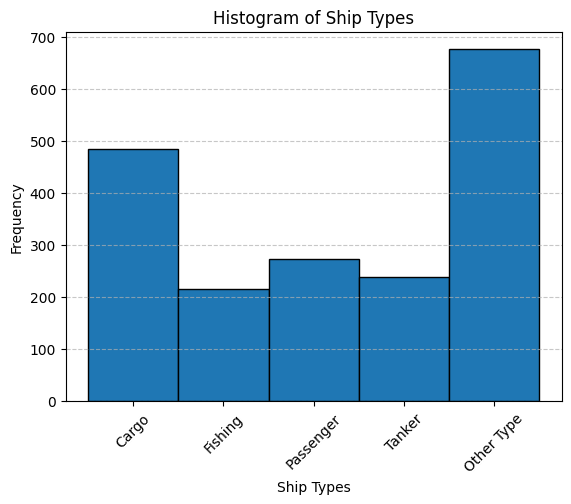

In [25]:
# Count frequency of each ship_name
ship_name_counts = Counter(ship_name_updated)


# Labels for each ship_name:
ship_name_label_map = {ship_nameii: idxii+1 for idxii, ship_nameii in enumerate(sorted(ship_name_counts.keys()))}
Labels    = [ship_name_label_map[p] for p in ship_name_updated] # Assigned label to each image


# Reorder the ship_name_label_map to set 'Other Type' as the last label:
ship_name_label_map = {name: idx for idx, name in enumerate(sorted(ship_name_label_map.keys(), key=lambda x: (x == 'Other Type', x)), start=1)}

# Update the Labels list accordingly
Labels = [ship_name_label_map[name] for name in ship_name_updated]

# Display the updated mapping
print(f"Labels (before removing the Other Types class): {ship_name_label_map}")
label_names = list(ship_name_label_map.keys())
N_classes = len(label_names)-1
print(f"Number of classes: {N_classes}")

plt.hist(Labels, bins=np.arange(1, len(label_names) + 2) - 0.5, edgecolor='black')
plt.xticks(ticks=np.arange(1, len(label_names) + 1), labels=label_names, rotation=45)
plt.xlabel('Ship Types')
plt.ylabel('Frequency')
plt.title('Histogram of Ship Types')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Train the Model 

# k-fold CV

In [26]:
# Load dependencies
from deep_functions import *
import torch
import torch.nn.functional as F
from torch import nn, optim
from torchvision import models, transforms
import timm
from torchinfo import summary

# Define processing device:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


cuda:0


In [27]:
# Mapping dictionary
mapping = {'inshore': 1, 'offshore': 2}

# New list with replacements
Labels_SL = np.asanyarray([mapping[loc] for loc in shoreline])


idx_all = np.arange(len(Labels))
idx_1 = idx_all[Labels_SL==1]
idx_2 = idx_all[Labels_SL==2]

In [28]:
# Ratio of train and validation samples:
tr_samples, val_samples = 0.7, 0. 

# Define batch size:
batch_size  =  16

# k-fold splits:
splits = 10

In [29]:
crop_images       = True; r_new, c_new = 256, 256 # Center crop images
# crop_images       = True; r_new, c_new = 448, 448 # Center crop images
reduce_resolution = True # 512x512 --> 256x256
data_augmentation = True # False #Data augmentation
balanced = False # True # 
aug_rep=1

In [ ]:
# Load all images to memory (to speed up training):
all_images  = load_images_to_memory(tif_dir)


if crop_images:
    r0, c0 = all_images.shape[2], all_images.shape[3]
    all_images = all_images[:,:, r0//2-r_new//2:r0//2+r_new//2, c0//2-c_new//2:c0//2+c_new//2]  


if reduce_resolution:
    # Reduce the Patch Resolution:
    def pooling(images, pool_size):
        n, c, h, w = images.shape
        # images_pooled = images.reshape(n, c, h // pool_size, pool_size, w // pool_size, pool_size).mean(axis=(3, 5))
        images_pooled = images.reshape(n, c, h // pool_size, pool_size, w // pool_size, pool_size).max(axis=(3, 5))
        return images_pooled 
    # Pooling for resolution reduction:
    all_images  = pooling(all_images, pool_size=2)

img_dim = all_images.shape[1:]
print("Image dimension:", img_dim)


AD_scores_all = np.zeros(all_images.shape)


from torchvision import transforms

# Define data augmentation transformations
augmentation_transformations = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.GaussianBlur(kernel_size=(5), sigma=(0.05, 0.5)),
    # transforms.RandomRotation(degrees=(-180,180)),
    # transforms.ColorJitter(brightness=(0,1e-8), contrast=(0,1), saturation=(0,10), hue=0),
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(size=img_dim[1:], scale=(0.9, 1.1)),
    # transforms.ToTensor()
])


In [ ]:
BackBone_args                  = {}
BackBone_args['model_name']    = 'tf_efficientnetv2_m.in1k'#'efficientnetv2_m'#'resnet50'#'convit_base'#'crossvit_base_240.in1k'#'tiny_vit_21m_512'#'tiny_vit_5m_224'#'resnext26ts'#'resnext50_32x4d.a1_in1k'#'densenet121' #'tf_efficientnetv2_l.in1k'#
BackBone_args['pretrained']    = True#False#
BackBone_args['features_only'] = True

FC_neurons = [256, 128, 64]; 
FC_dropout = [0.25, 0.25, 0.25] #  

num_ensemble = 1
input_CBAM = False


In [32]:
num_reps = 3 # Number of repetitions for training to ensure robustness
num_epochs = 40

learning_rate = 1.5*1e-4 

In [33]:
kfoldCV_out                 = {}
kfoldCV_out['model']        = []
kfoldCV_out['loss_history'] = []
kfoldCV_out['cm_tr']        = []
kfoldCV_out['cm_val']       = []
kfoldCV_out['y_true_tr']    = []
kfoldCV_out['y_pred_tr']    = []
kfoldCV_out['y_true_val']   = []
kfoldCV_out['y_pred_val']   = []
sii = 0

In [34]:
if len(label_names)>2:
    if 'Other Type' in label_names:
        label_names.remove('Other Type')
print("Label names used:", label_names)

Label names used: ['Cargo', 'Fishing', 'Passenger', 'Tanker']


In [35]:
# export_folder = f"{samples_loc}_{'_'.join(label_names)}"
export_folder = f"NEW_{samples_loc}_{'_'.join(label_names)}"
export_folder = f"NEW2026_{samples_loc}_{'_'.join(label_names)}"

benchmark_pathes = [
    "BenchMarkResults",
    f"BenchMarkResults/{export_folder}",
    f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}",
    f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Weights",
    f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Weights/Full",
    f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Weights/BackBoneOnly"
]

for pathii in benchmark_pathes:
    if not os.path.exists(pathii):
        os.mkdir(pathii)
        print(f"Created directory: {pathii}")
    else:
        print(f"Directory already exists: {pathii}")


Directory already exists: BenchMarkResults
Directory already exists: BenchMarkResults/NEW2026_InShoreOffShore_Cargo_Fishing_Passenger_Tanker
Directory already exists: BenchMarkResults/NEW2026_InShoreOffShore_Cargo_Fishing_Passenger_Tanker/BenchMarkResults_tf_efficientnetv2_m.in1k
Directory already exists: BenchMarkResults/NEW2026_InShoreOffShore_Cargo_Fishing_Passenger_Tanker/BenchMarkResults_tf_efficientnetv2_m.in1k/Weights
Directory already exists: BenchMarkResults/NEW2026_InShoreOffShore_Cargo_Fishing_Passenger_Tanker/BenchMarkResults_tf_efficientnetv2_m.in1k/Weights/Full
Directory already exists: BenchMarkResults/NEW2026_InShoreOffShore_Cargo_Fishing_Passenger_Tanker/BenchMarkResults_tf_efficientnetv2_m.in1k/Weights/BackBoneOnly


In [ ]:
# k-fold CV:

print(f"======================== Starting {splits}-Fold Cross-Validation using {BackBone_args['model_name']}========================\n")

import gc
for sii in range(sii, splits):
    print(f"\n======================== Split {sii+1}/{splits} ========================")
    gc.collect()                   # free Python memory
    
    torch.cuda.empty_cache()   # release cached GPU blocks

    # Reset random seed for Reproducibility:
    os.environ["PYTHONHASHSEED"] = str(sii)
    np.random.seed(sii)
    random.seed(sii)
    torch.manual_seed(sii)
    torch.cuda.manual_seed(sii)
    torch.cuda.manual_seed_all(sii)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"random seed: {sii}")

    try:
        del backbone
        del model_CNN
        del optimizer
        del scheduler_class
    except:
        pass
    
    # 1- Train and Validation Samples:
    
    # 1-1- Find Train and Validation Samples:
    # tr_label, _, val_label, tr_idx, _, val_idx = tr_te_sample( np.array(Labels), tr_samples, val_samples, random_seed=sii )

    # # # Stratified sampling based on Shoreline Labels (Inshore and Offshore)
    tr_label1, _, val_label1, tr_idx1, _, val_idx1 = tr_te_sample( np.array(Labels)[Labels_SL==1], tr_samples, val_samples, random_seed=sii )
    tr_label2, _, val_label2, tr_idx2, _, val_idx2 = tr_te_sample( np.array(Labels)[Labels_SL==2], tr_samples, val_samples, random_seed=sii )
    print(f"Train samples per class (Inshore): {np.unique_counts(tr_label1)[1]}, (Offshore): {np.unique_counts(tr_label2)[1]}")
    print(f"Validation samples per class (Inshore): {np.unique_counts(val_label1)[1]}, (Offshore): {np.unique_counts(val_label2)[1]}")
    tr_label = np.hstack( (tr_label1, tr_label2) )
    val_label = np.hstack( (val_label1, val_label2) )
    tr_idx = np.hstack( (idx_1[tr_idx1], idx_2[tr_idx2]) )
    val_idx = np.hstack( (idx_1[val_idx1], idx_2[val_idx2]) )

    # 1-2- Remove the maximum label (Other Type) from training and validation sets
    if np.max(Labels)>2:
        tr_idx    = tr_idx  [tr_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from training set
        tr_label  = tr_label[tr_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from training labels

        val_idx   = val_idx  [val_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from validation set
        val_label = val_label[val_label!=np.max(Labels)]  # Remove the maximum label (Other Type) from validation labels

        label_names = list(ship_name_label_map.keys())[:-1]

        print(f"Training samples: {len(tr_idx)}, Validation samples: {len(val_idx)} [Excluding 'Other Type']")
    else:
        print(f"Training samples: {len(tr_idx)}, Validation samples: {len(val_idx)} ['Other Type' was not excluded]") 
    print(f"label names: {label_names}")


    # 1-3- Find tif file pathes and load the images:
    im_path_tr  = [tif_dir[ii] for ii in tr_idx]
    im_path_val = [tif_dir[ii] for ii in val_idx]

    tr_images  = all_images[tr_idx]
    val_images = all_images[val_idx]
    

    # 3- Dataloader:
    # 3-1- Initial Dataloader:
    tr_dataset     = ShipDatasetMemory(images=tr_images, features=None, labels=tr_label)
    val_dataset    = ShipDatasetMemory(images=val_images, features=None, labels=val_label)

    tr_dataloader0  = DataLoader(tr_dataset, batch_size=batch_size, shuffle=True)#, generator=g)
    val_dataloader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)#, generator=g)

    # 3-2- Data Augmentation:
    if data_augmentation:
        print("Applying Data Augmentation...")

        _, label_counts_tr = np.unique(tr_label, return_counts=True)
        if balanced:
            X_aug_all, AD_score_aug_all, y_aug_all = Augmentation_Samples(images=tr_images, features=None, labels=tr_label, 
                                                                        transformations=augmentation_transformations, batch_size=batch_size, rep=aug_rep)
            _, label_counts_aug = np.unique(y_aug_all, return_counts=True)
            
            for ii, countii in enumerate(label_counts_aug):
                N_max = max(label_counts_aug)+max(label_counts_tr)-label_counts_tr[ii]
                
                while countii < N_max:
                    X_aug_ii, AD_score_aug_ii, y_aug_ii = Augmentation_Samples(images=tr_images, features=None, labels=tr_label, 
                                                                                transformations=augmentation_transformations, batch_size=batch_size, rep=1)
                    X_aug_ii        = X_aug_ii[y_aug_ii==ii+1][:N_max-countii]
                    AD_score_aug_ii = AD_score_aug_ii[y_aug_ii==ii+1][:N_max-countii]
                    y_aug_ii        = y_aug_ii[y_aug_ii==ii+1][:N_max-countii]

                    X_aug_all       = np.concatenate((X_aug_all, X_aug_ii), axis=0)
                    AD_score_aug_all= np.concatenate((AD_score_aug_all, AD_score_aug_ii), axis=0)
                    y_aug_all       = np.concatenate((y_aug_all, y_aug_ii), axis=0)
                    
                    countii += len(y_aug_ii)
            class_weights = np.array([1.0]*N_classes)
        else:
            X_aug_all, AD_score_aug_all, y_aug_all = Augmentation_Samples(images=tr_images, features=None, labels=tr_label, 
                                                                        transformations=augmentation_transformations, batch_size=batch_size, rep=aug_rep)

        # 3-2-1 Merging Augmented data with the main data:
        tr_merged_images = np.concatenate((tr_dataset.images, X_aug_all), axis=0)
        tr_merged_labels = np.concatenate((tr_dataset.labels, y_aug_all), axis=0)
        
        # 3-2-2 Create a new dataset with the merged data:
        tr_dataset_merged = ShipDatasetMemory(tr_merged_images, features=None, labels=tr_merged_labels, transform=None)
        
        # 3-2-3 Augmented DataLoader:
        tr_dataloader  = DataLoader(tr_dataset_merged, batch_size=batch_size, shuffle=True)#, generator=g)
        print(f"Training samples after augmentation: {len(tr_dataloader.dataset)} in {len(tr_dataloader)} batches.")

    else:
        tr_dataloader  = DataLoader(tr_dataset, batch_size=batch_size, shuffle=True)#, generator=g) # No Augmentation [Comment if you want data augmentation]
    

    # 4- Model:

    # 4-1- Define Model:
    backbone = CNNBackBone( model_name   = BackBone_args['model_name'],
                            in_channels  = img_dim[0],
                            pretrained   = BackBone_args['pretrained'],
                            features_only= BackBone_args['features_only']
                        ).to(device)
    FC_input_dim = backbone( torch.randn(batch_size, img_dim[0], img_dim[1], img_dim[2]).to(device=device) ).shape[1]
    # backbone = '' # No backbone
    
    model_CNN  = DeepModel( in_channels   = img_dim[0],
                            num_classes   = N_classes,
                            BackBone      = backbone,
                            FC_input_dim  = FC_input_dim,
                            FC_neurons    = FC_neurons,
                            num_ensemble  = num_ensemble,
                            FC_dropout    = FC_dropout, 
                            input_CBAM    = input_CBAM
                        ).to(device)
    # model_CNN = timm.create_model(BackBone_args['model_name'], pretrained=True, num_classes=N_classes, in_chans=img_dim[0]).to(device) # Vit

    model_CNN.train()  # Set model to training mode
    if sii==0:
        print( summary( model_CNN, input_size=(1, img_dim[0], img_dim[1], img_dim[2]) ) )
    else:
        summary( model_CNN, input_size=(1, img_dim[0], img_dim[1], img_dim[2]) )

    # 4-2- Optimizer and Scheduler:
    optimizer = torch.optim.Adam(model_CNN.parameters(), lr=learning_rate, weight_decay=1e-6) # weight_decay: alpha coefficient for weight L2 regularization
    # optimizer = torch.optim.SGD(model_CNN.parameters(), lr=learning_rate, weight_decay=1e-8) # weight_decay: alpha coefficient for weight L2 regularization
    # Learning rate scheduler
    scheduler_class = lambda optimizer: torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # 5- Training Loop:
    
    # Class weights for imbalanced dataset:
    from sklearn.utils.class_weight import compute_class_weight

    # Compute class weights based on frequency of each class in tr_label
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(tr_label),
        y=tr_label
    ) 
    
    # class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    class_weights_tensor = class_weights_from_counts(np.unique_counts(tr_label)[1], beta=0.99).to(device)

    # os.remove("model_CNN_temp_weights.pth")
    model_CNN, loss_history = train_model(model        = model_CNN, 
                                  tr_dataloader        = tr_dataloader, 
                                  val_dataloader       = val_dataloader, 
                                  N_classes            = N_classes,
                                  optimizer            = optimizer, 
                                  scheduler_class      = scheduler_class, 
                                  class_weights_tensor = class_weights_tensor, 
                                  SM_temp              = 1,#4, # Softmax temperature
                                  num_epochs           = num_epochs,
                                  num_reps             = num_reps, 
                                  weight_export_name   = "model_CNN_temp_weights.pth",
                                  physics_guided       = False#True#
                                  )
    torch.save(model_CNN.state_dict(), f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Weights/Full/{BackBone_args['model_name']}_FullModel_seed{sii}.pth")
    torch.save(backbone.state_dict(), f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Weights/BackBoneOnly/{BackBone_args['model_name']}_BackBoneOnly_seed{sii}.pth")
    os.remove("model_CNN_temp_weights.pth")
    
    # 6- Inference
    y_true_tr, y_pred_tr, cm_tr, oa_tr     = model_inference(model_CNN, tr_dataloader0, label_names=label_names, device=device, show=False)
    y_true_val, y_pred_val, cm_val, oa_val = model_inference(model_CNN, val_dataloader, label_names=label_names, device=device, show=False)
    
    kfoldCV_out['model'].append(model_CNN)
    kfoldCV_out['loss_history'].append(loss_history)

    kfoldCV_out['cm_tr'].append(cm_tr)
    kfoldCV_out['cm_val'].append(cm_val)
    
    kfoldCV_out['y_true_tr'].append(y_true_tr)
    kfoldCV_out['y_pred_tr'].append(y_pred_tr)
    
    kfoldCV_out['y_true_val'].append(y_true_val)
    kfoldCV_out['y_pred_val'].append(y_pred_val)
    CM_ii = confusion_mat(y_true_val, y_pred_val, list(ship_name_label_map.keys())[:-1], plot=False)


In [ ]:
# Confusion Matrix for Validation sets across all folds:
if not os.path.exists(f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Classification Results"):
    os.mkdir(f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Classification Results")
sii = 0
true_all = []
pred_all = []
for trueii, predii in zip(kfoldCV_out['y_true_val'], kfoldCV_out['y_pred_val']):
    true_all.append(trueii)
    pred_all.append(predii)
    savefig_path = f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Classification Results/Confusion_Matrix_Validation_seed{sii}.jpeg"
    
    CM_ii = confusion_mat(trueii, predii, list(ship_name_label_map.keys())[:-1], savefig_path=savefig_path, plot=True,cmap="gray_r")

    sii+=1
true_all = np.concatenate(true_all)
pred_all = np.concatenate(pred_all)

In [ ]:
plot_metrics_bar_chart(kfoldCV_out['cm_val'], list(ship_name_label_map.keys())[:-1])
plt.savefig(f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Classification Results/Bar_Chart_Validation.jpeg", dpi=400)

In [ ]:
OA, AA, APr, AF1 = compute_metrics_from_confusion_matrix(kfoldCV_out['cm_val'])
plot_metrics_summary(OA, AA, APr, AF1, kfoldCV_out['cm_val'])

plt.savefig(f"BenchMarkResults/{export_folder}/BenchMarkResults_{BackBone_args['model_name']}/Classification Results/ConfusionMat_Bar_Chart_Validation.jpeg", dpi=400)
